In [1]:
import pandas as pd

df = pd.read_csv(
    "C:\\Users\\loloa\\OneDrive\\Escritorio\\facu\\Ciencia de datos\\trabajo_final\\TP-Final-Ciencia-de-Datos\\Base Aprender Estudiantes 6 Grado Primaria 2023 (3).csv",
    sep=";",       # si no funciona con "," probá con ";"
    encoding="latin1"  # si no funciona, probá "utf-8"
)

In [2]:
import numpy as np
import pandas as pd

# Convertir todas las columnas a numérico si es posible
df = df.apply(pd.to_numeric, errors='coerce')

In [3]:
# Reemplazar -9/-8/-6 por NaN y asegurarnos de que sean numéricas
cols = ["sector", "ambito", "ap01"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

# (Opcional) eliminar filas que tengan NaN en cualquiera de estas 3 columnas
df = df.dropna(subset=cols)
# sector: 1=Estatal, 2=Privado → col 0/1 para "Privado"
df["sector_privado"] = (df["sector"] == 2).astype(int)

# ambito: 1=Rural, 2=Urbano → col 0/1 para "Urbano"
df["ambito_urbano"] = (df["ambito"] == 2).astype(int)

# (Recomendado para PCA) quitar las originales nominales
df = df.drop(columns=["sector", "ambito"])

In [4]:
# Limpiar y crear dummies para ap03
df["ap03"] = pd.to_numeric(df["ap03"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})
df = df.dropna(subset=["ap03"])  # eliminar filas con NaN

df = pd.get_dummies(df, columns=["ap03"], prefix="sexo", drop_first=True)
# crea sexo_2 (Femenino) y sexo_3 (X)
df = df.astype({col: "int" for col in df.select_dtypes(bool).columns})

In [5]:
print(df.head(10))

           ï»¿ID1  jurisdiccion  seccion  idalumno  ap01  ap02  ap04  ap05a  \
0  20004002000400            50        1    247287   2.0   1.0   1.0    1.0   
1  20004002000400            50        2    247266   3.0   9.0   1.0    1.0   
2  20004002000400            50        1    247288   3.0   9.0   1.0    2.0   
3  20004002000400            50        1    247289   2.0   1.0   1.0    1.0   
4  20004002000400            50        1    247290   2.0  12.0   1.0    1.0   
5  20004002000400            50        1    247291   3.0   8.0   1.0    1.0   
6  20004002000400            50        1    247292   2.0  10.0   1.0   -9.0   
7  20004002000400            50        1    247293   2.0   2.0   1.0   -9.0   
8  20004002000400            50        1    247294   3.0   7.0   1.0    1.0   
9  20004002000400            50        1    247295   3.0   8.0   1.0    1.0   

   ap05b  ap05c  ...  migracion  sobreedad  Nivel_Ed_Madre  Nivel_Ed_Padre  \
0    1.0    1.0  ...          2          1          

In [6]:
# Nos aseguramos de que idalumno sea numérico (por si acaso)
df["idalumno"] = pd.to_numeric(df["idalumno"], errors="coerce")

# Agrupar por idalumno (en caso de que haya más de una observación por alumno)
# y tomar la media o el máximo según corresponda
df1 = (
    df.groupby("idalumno", as_index=False)
      .agg({
          "ap01": "mean",            # Edad (promedio si hay duplicados)
          "sector_privado": "max",   # 1 si alguna observación es privada
          "ambito_urbano": "max",    # 1 si alguna observación es urbana
          "sexo_2.0": "max",           # 1 si Femenino
          "sexo_3.0": "max"            # 1 si X
      })
      .rename(columns={"ap01": "ap01_edad_index"})
)

In [7]:
# Definir columnas del bloque
ap05_cols = [f"ap05{c}" for c in list("abcdefgh")]

# Limpiar y convertir valores
df[ap05_cols] = df[ap05_cols].apply(pd.to_numeric, errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

# Mapear respuestas: 1 = Sí, 2 = No
df[ap05_cols] = df[ap05_cols].replace({1: 1, 2: 0})

# Crear el índice como promedio de respuestas (NaN no se cuenta)
df["ap05_index"] = df[ap05_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir a df1
ap05_index = df.groupby("idalumno", as_index=False)["ap05_index"].mean()
df1 = df1.merge(ap05_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_11560\501448138.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap05_index"] = df[ap05_cols].mean(axis=1, skipna=True)


In [8]:
# Definir columnas del bloque
ap06_cols = [f"ap06{c}" for c in list("abcde")]

# Limpiar valores inválidos
df[ap06_cols] = df[ap06_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Crear índice como promedio de las respuestas válidas
df["ap06_index"] = df[ap06_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir al df1
ap06_index = df.groupby("idalumno", as_index=False)["ap06_index"].mean()
df1 = df1.merge(ap06_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_11560\476429443.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap06_index"] = df[ap06_cols].mean(axis=1, skipna=True)


In [9]:
# Definir columnas del bloque
ap07_cols = ["ap07a", "ap07b"]

# Limpiar valores inválidos
df[ap07_cols] = df[ap07_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Crear índice como promedio de las respuestas válidas
df["ap07_index"] = df[ap07_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir al df1
ap07_index = df.groupby("idalumno", as_index=False)["ap07_index"].mean()
df1 = df1.merge(ap07_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_11560\1789343149.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap07_index"] = df[ap07_cols].mean(axis=1, skipna=True)


In [10]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         0   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  
0         0      1.0000       2.200        2.75  
1         0      0.6875       1.875        1.00  
2         0      0.5625       1.350        1.0

In [11]:
# Definir columnas del bloque
ap09_cols = [f"ap09{c}" for c in list("abcdefghijk")]

# Limpiar valores inválidos
df[ap09_cols] = df[ap09_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Mapear respuestas: 1 = Sí, 2 = No
df[ap09_cols] = df[ap09_cols].replace({1: 1, 2: 0})

# Crear índice como promedio de respuestas válidas (ignora NaN)
df["ap09_index"] = df[ap09_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir a df1
ap09_index = df.groupby("idalumno", as_index=False)["ap09_index"].mean()
df1 = df1.merge(ap09_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_11560\1902926127.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap09_index"] = df[ap09_cols].mean(axis=1, skipna=True)


In [12]:
# Variables del bloque
cols_ap10_15 = ["ap10", "ap11", "ap12", "ap13", "ap14", "ap15"]

# Asegurar formato numérico y limpiar códigos inválidos
df[cols_ap10_15] = df[cols_ap10_15].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Unir al df1 (puede haber NaN)
df_temp = df[["idalumno"] + cols_ap10_15].copy()
df_temp = df_temp.groupby("idalumno", as_index=False).mean()

# Renombrar columnas para claridad
df_temp = df_temp.rename(columns={
    "ap10": "ap10_libros",
    "ap11": "ap11_si_no",
    "ap12": "ap12_si_no",
    "ap13": "ap13_si_no",
    "ap14": "ap14_cantidad",
    "ap15": "ap15_cantidad"
})

# Agregar al df1 (sin eliminar nada todavía)
df1 = df1.merge(df_temp, on="idalumno", how="left")

In [13]:
# Eliminar de df1 las filas que tengan NA en cualquiera de estas columnas
df1 = df1.dropna(subset=[
    "ap10_libros", "ap11_si_no", "ap12_si_no",
    "ap13_si_no", "ap14_cantidad", "ap15_cantidad"
])

In [14]:
df1= df1.dropna()

VER

In [15]:
# Definir columnas del bloque
cols_ap18_19 = [f"ap18{c}" for c in list("abcd")] + [f"ap19{c}" for c in list("abcd")]

# Convertir a numérico y limpiar valores inválidos
df[cols_ap18_19] = df[cols_ap18_19].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Mapear respuestas: 1 = Sí → 1, 2 = No → 0
df[cols_ap18_19] = df[cols_ap18_19].replace({1: 1, 2: 0})

# Agrupar por idalumno, usando el máximo (1 si alguna vez fue Sí)
ap18_19 = df.groupby("idalumno", as_index=False)[cols_ap18_19].max()

# Unir a df1
df1 = df1.merge(ap18_19, on="idalumno", how="left")

In [16]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         7              2.0               0              1         1   
6         8              2.0               0              1         0   
7         9              2.0               0              1         0   
8        11              2.0               0              1         0   
9        12              2.5               0              1         1   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  \
0         0      1.0000       2.200        2.75    0.772727  ...   
1         0      0.6875       1.875        1.00    0.863636 

In [17]:
# Verificar cuántos duplicados hay
print("Cantidad de filas duplicadas:", df["idalumno"].duplicated().sum())

# Eliminar duplicados, quedándote con la primera ocurrencia
df1 = df1.drop_duplicates(subset="idalumno", keep="first")

# Confirmar que no queden duplicados
print("Duplicados después de limpiar:", df1["idalumno"].duplicated().sum())

Cantidad de filas duplicadas: 24
Duplicados después de limpiar: 0


In [18]:
df1= df1.dropna()

In [19]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 54577


In [20]:
# Variables del bloque
cols_ap21_22 = ["ap22"]

# Convertir a numérico y limpiar valores inválidos
df[cols_ap21_22] = df[cols_ap21_22].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Eliminar filas con NaN en estas preguntas
df = df.dropna(subset=cols_ap21_22)

# Crear dummies para cada variable
dummies_ap22 = pd.get_dummies(df["ap22"], prefix="ap22", dtype=int)

# Unir las dummies al DataFrame original
df_dummies = pd.concat([df[["idalumno"]], dummies_ap22], axis=1)

# Agrupar por idalumno (por si hay repetidos)
df_dummies = df_dummies.groupby("idalumno", as_index=False).max()

# Unir al df1
df1 = df1.merge(df_dummies, on="idalumno", how="left")

In [21]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         2              2.0               0              1         0   
1         5              2.0               0              1         1   
2        15              2.5               0              1         0   
3        18              2.5               0              1         1   
4        19              2.0               0              1         1   
5        21              2.0               0              1         0   
6        32              2.0               0              1         0   
7        65              3.0               0              1         1   
8       131              2.0               0              0         1   
9       171              2.0               0              0         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap18c  \
0         0    0.687500       1.875        1.00    0.863636  ...    0.0   
1         0    1.000000       1.900        1.5

In [24]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 54577


In [25]:
# Definir columnas del bloque
cols_ap25 = [f"ap25{c}" for c in list("abcdefghij")]

# Convertir a numérico y reemplazar -8 y -9 por 0
df[cols_ap25] = df[cols_ap25].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0
})

# Agrupar por idalumno (por si hay duplicados) y tomar el máximo
# (si alguna vez seleccionó 1, queda 1)
ap25 = df.groupby("idalumno", as_index=False)[cols_ap25].max()

# Unir al df1
df1 = df1.merge(ap25, on="idalumno", how="left")

In [26]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         2              2.0               0              1         0   
1         5              2.0               0              1         1   
2        15              2.5               0              1         0   
3        18              2.5               0              1         1   
4        19              2.0               0              1         1   
5        21              2.0               0              1         0   
6        32              2.0               0              1         0   
7        65              3.0               0              1         1   
8       131              2.0               0              0         1   
9       171              2.0               0              0         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25a  \
0         0    0.687500       1.875        1.00    0.863636  ...    1.0   
1         0    1.000000       1.900        1.5

In [27]:
# Variable
col_ap26 = "ap26"

# Convertir a numérico y limpiar
df[col_ap26] = pd.to_numeric(df[col_ap26], errors="coerce")

# Reemplazar -9, -8, -6 por NaN
df[col_ap26] = df[col_ap26].replace({-9: np.nan, -8: np.nan, -6: np.nan})

# Calcular la moda (valor más frecuente, ignorando NaN)
moda_ap26 = df[col_ap26].mode()[0]
print("La opción más frecuente en ap26 es:", moda_ap26)

# Reemplazar NaN con la moda
df[col_ap26] = df[col_ap26].fillna(moda_ap26)

# Agrupar por idalumno (por si hay duplicados)
ap26 = df.groupby("idalumno", as_index=False)[col_ap26].max()

# Unir al df1
df1 = df1.merge(ap26, on="idalumno", how="left")

La opción más frecuente en ap26 es: 1.0


In [28]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         2              2.0               0              1         0   
1         5              2.0               0              1         1   
2        15              2.5               0              1         0   
3        18              2.5               0              1         1   
4        19              2.0               0              1         1   
5        21              2.0               0              1         0   
6        32              2.0               0              1         0   
7        65              3.0               0              1         1   
8       131              2.0               0              0         1   
9       171              2.0               0              0         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25b  \
0         0    0.687500       1.875        1.00    0.863636  ...    0.0   
1         0    1.000000       1.900        1.5

In [29]:
# Definir las columnas del bloque
cols_apA34 = [f"apA34{c}" for c in list("abcdefghijklm")]

# Convertir a numérico y reemplazar valores inválidos por 0
df[cols_apA34] = df[cols_apA34].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0, 2: 0, 1: 1
})

# Crear el índice sumando todos los "Sí" (1) por alumno
apA34_index = (
    df.groupby("idalumno", as_index=False)[cols_apA34]
    .sum()
    .assign(indice_apA34=lambda x: x[cols_apA34].sum(axis=1))
    [["idalumno", "indice_apA34"]]
)

# Unir el índice al df1
df1 = df1.merge(apA34_index, on="idalumno", how="left")

In [30]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         2              2.0               0              1         0   
1         5              2.0               0              1         1   
2        15              2.5               0              1         0   
3        18              2.5               0              1         1   
4        19              2.0               0              1         1   
5        21              2.0               0              1         0   
6        32              2.0               0              1         0   
7        65              3.0               0              1         1   
8       131              2.0               0              0         1   
9       171              2.0               0              0         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25c  \
0         0    0.687500       1.875        1.00    0.863636  ...    1.0   
1         0    1.000000       1.900        1.5

In [31]:
# Definir las columnas del bloque
cols_apA36 = [f"apA36{c}" for c in list("abcde")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36] = df[cols_apA36].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Reescalar las respuestas según el puntaje positivo (4 = siempre, 1 = nunca)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36] = df[cols_apA36].replace(mapa_puntaje)

# Calcular el índice de bienestar (suma total de los puntajes)
apA36_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36]
    .sum()
    .assign(apA36_positivo=lambda x: x[cols_apA36].sum(axis=1))
    [["idalumno", "apA36_positivo"]]
)

# Unir el índice al df1
df1 = df1.merge(apA36_index, on="idalumno", how="left")

In [32]:
# Definir columnas del bloque negativo
cols_apA36_neg = [f"apA36{c}" for c in list("fgh")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36_neg] = df[cols_apA36_neg].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Mapear puntajes (1 = Siempre → 4 puntos, 4 = Nunca → 1 punto)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36_neg] = df[cols_apA36_neg].replace(mapa_puntaje)

# Calcular el índice de malestar (suma total)
apA36_neg_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36_neg]
    .sum()
    .assign(apA36_index_negativo=lambda x: x[cols_apA36_neg].sum(axis=1))
    [["idalumno", "apA36_index_negativo"]]
)

# Unir al df1
df1 = df1.merge(apA36_neg_index, on="idalumno", how="left")
# Definir columnas del bloque negativo
cols_apA36_neg = [f"apA36{c}" for c in list("fgh")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36_neg] = df[cols_apA36_neg].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Mapear puntajes (1 = Siempre → 4 puntos, 4 = Nunca → 1 punto)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36_neg] = df[cols_apA36_neg].replace(mapa_puntaje)

# Calcular el índice de malestar (suma total)
apA36_neg_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36_neg]
    .sum()
    .assign(apA36_index_negativo=lambda x: x[cols_apA36_neg].sum(axis=1))
    [["idalumno", "apA36_index_negativo"]]
)

# Unir al df1
df1 = df1.merge(apA36_neg_index, on="idalumno", how="left")

VER

In [33]:
# Definir las columnas del bloque
cols_apA38 = [f"apA38{c}" for c in list("abcdefghijk")]

# Convertir a numérico y reemplazar -9 y -8 por 0
df[cols_apA38] = df[cols_apA38].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0
})

# Agrupar por alumno (por si hay duplicados) y tomar el máximo (si alguna vez seleccionó, queda 1)
apA38 = df.groupby("idalumno", as_index=False)[cols_apA38].max()

# Crear el índice sumando todos los motivos seleccionados
apA38["indice_discriminacion"] = apA38[cols_apA38].sum(axis=1)

# Unir al df1
df1 = df1.merge(apA38[["idalumno", "indice_discriminacion"]], on="idalumno", how="left")

In [34]:
df1["indice_discriminacion"].value_counts().sort_index()

indice_discriminacion
0.0     41640
1.0      6592
2.0      1746
3.0      1164
4.0       767
5.0       654
6.0       584
7.0       380
8.0       222
9.0       168
10.0      132
11.0      528
Name: count, dtype: int64

In [35]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 54577


In [36]:
# Aseguramos que sean numéricas y válidas
cols_desemp = ["ldesemp", "mdesemp"]
df[cols_desemp] = df[cols_desemp].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# (Opcional) eliminamos filas con NaN en estas columnas
df = df.dropna(subset=cols_desemp)

# Unimos al df1 por idalumno
df1 = df1.merge(df[["idalumno"] + cols_desemp], on="idalumno", how="left")

In [37]:

# Agregamos NSE_nivel a df1
df1 = df1.merge(df[["idalumno", "NSE_nivel"]], on="idalumno", how="left")


In [38]:
# Limpiar y recodificar variable 'migracion'
df["migracion"] = pd.to_numeric(df["migracion"], errors="coerce").replace({
    -9: np.nan,   # valores faltantes
    2: 0          # 2 -> no migrante
    # 1 queda como migrante (1)
})

# Unir a df1
df1 = df1.merge(df[["idalumno", "migracion"]], on="idalumno", how="left")



In [39]:
# Limpiar y recodificar 'sobreedad'
df["sobreedad"] = pd.to_numeric(df["sobreedad"], errors="coerce").replace({
    -9: np.nan,  # blanco -> NA
    0: 0,        # menor o edad teórica -> 0
    1: 0,        # idem
    2: 1,        # 1 año de sobreedad
    3: 2,        # 2 años
    4: 3         # 3 años o más
})

# Unir al df1
df1 = df1.merge(df[["idalumno", "sobreedad"]], on="idalumno", how="left")


In [40]:
# Asegurar tipo numérico (por las dudas)
cols_edu = ["Nivel_Ed_Madre", "Nivel_Ed_Padre"]
df[cols_edu] = df[cols_edu].apply(pd.to_numeric, errors="coerce")

# Unir al df1
df1 = df1.merge(df[["idalumno"] + cols_edu], on="idalumno", how="left")

In [41]:
# Aseguramos que sea numérica por las dudas
df["clima_escolar"] = pd.to_numeric(df["clima_escolar"], errors="coerce")

# Unimos a df1
df1 = df1.merge(df[["idalumno", "clima_escolar"]], on="idalumno", how="left")

In [42]:
df1.isna().sum()

idalumno              0
ap01_edad_index       0
sector_privado        0
ambito_urbano         0
sexo_2.0              0
                   ... 
migracion          3265
sobreedad          2326
Nivel_Ed_Madre     2326
Nivel_Ed_Padre     2326
clima_escolar      2402
Length: 63, dtype: int64

In [43]:
df1=df1.dropna()

In [44]:
df1.isna().sum()

idalumno           0
ap01_edad_index    0
sector_privado     0
ambito_urbano      0
sexo_2.0           0
                  ..
migracion          0
sobreedad          0
Nivel_Ed_Madre     0
Nivel_Ed_Padre     0
clima_escolar      0
Length: 63, dtype: int64

PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

 #1️⃣ Definir las variables que vas a incluir en el PCA (todas menos idalumno)
X = df1.drop(columns=["idalumno"])

 #2️⃣ Escalar los datos (media=0, varianza=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Aplicar PCA
pca = PCA(n_components=0.9)  # Retiene componentes que explican el 90% de la varianza total
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ Ver cuánta varianza explica cada componente
import pandas as pd
explained_var = pd.DataFrame({
    "Componente": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza explicada (%)": pca.explained_variance_ratio_ * 100,
    "Varianza acumulada (%)": pca.explained_variance_ratio_.cumsum() * 100
})
explained_var.head(10)

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,1,10.276276,10.276276
1,2,5.649160,15.925436
2,3,5.244482,21.169918
3,4,4.604052,25.773970
4,5,3.807594,29.581564
5,6,2.896809,32.478373
6,7,2.575476,35.053849
7,8,2.279867,37.333716
8,9,2.168729,39.502445
9,10,2.017574,41.520019


In [ ]:
#Crear un DataFrame con los loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

 Mostrar las 10 variables que más contribuyen al primer componente
print("🔹 Variables más importantes en el PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

🔹 Variables más importantes en el PC1:
ap19a      0.322182
ap19c      0.320408
ap19d      0.318569
ap19b      0.317428
ap18a      0.315274
ap18c      0.313425
ap18b      0.311755
ap18d      0.310192
ldesemp    0.164173
mdesemp    0.145319
Name: PC1, dtype: float64


In [47]:
df1.head()

,idalumno,ap01_edad_index,sector_privado,ambito_urbano,sexo_2.0,sexo_3.0,ap05_index,ap06_index,ap07_index,ap09_index,...,apA36_index_negativo_y,indice_discriminacion,ldesemp,mdesemp,NSE_nivel,migracion,sobreedad,Nivel_Ed_Madre,Nivel_Ed_Padre,clima_escolar
0,2,2.0,0,1,0,0,0.6875,1.875,1.0,0.863636,...,10.0,0.0,1.0,2.0,2.0,0.0,0.0,5.0,3.0,2.0
1,2,2.0,0,1,0,0,0.6875,1.875,1.0,0.863636,...,10.0,0.0,1.0,2.0,2.0,0.0,0.0,5.0,3.0,2.0
2,2,2.0,0,1,0,0,0.6875,1.875,1.0,0.863636,...,10.0,0.0,1.0,2.0,2.0,0.0,0.0,6.0,6.0,2.0
3,2,2.0,0,1,0,0,0.6875,1.875,1.0,0.863636,...,10.0,0.0,1.0,2.0,2.0,0.0,0.0,6.0,6.0,2.0
4,2,2.0,0,1,0,0,0.6875,1.875,1.0,0.863636,...,10.0,0.0,1.0,2.0,2.0,0.0,0.0,5.0,3.0,2.0


In [48]:
df1.columns.tolist()

['idalumno',
 'ap01_edad_index',
 'sector_privado',
 'ambito_urbano',
 'sexo_2.0',
 'sexo_3.0',
 'ap05_index',
 'ap06_index',
 'ap07_index',
 'ap09_index',
 'ap10_libros',
 'ap11_si_no',
 'ap12_si_no',
 'ap13_si_no',
 'ap14_cantidad',
 'ap15_cantidad',
 'ap18a',
 'ap18b',
 'ap18c',
 'ap18d',
 'ap19a',
 'ap19b',
 'ap19c',
 'ap19d',
 'ap22_1.0',
 'ap22_2.0',
 'ap22_3.0',
 'ap22_4.0',
 'ap24a',
 'ap24b',
 'ap24c',
 'ap24d',
 'ap24e',
 'ap24f',
 'ap24g',
 'ap24h',
 'ap24i',
 'ap24j',
 'ap24k',
 'ap25a',
 'ap25b',
 'ap25c',
 'ap25d',
 'ap25e',
 'ap25f',
 'ap25g',
 'ap25h',
 'ap25i',
 'ap25j',
 'ap26',
 'indice_apA34',
 'apA36_positivo',
 'apA36_index_negativo_x',
 'apA36_index_negativo_y',
 'indice_discriminacion',
 'ldesemp',
 'mdesemp',
 'NSE_nivel',
 'migracion',
 'sobreedad',
 'Nivel_Ed_Madre',
 'Nivel_Ed_Padre',
 'clima_escolar']

In [49]:
df1.shape

(51553, 63)

In [50]:
df["ap23"] = pd.to_numeric(df["ap23"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})
df = df.dropna(subset=["ap23"])
df["ap23"].value_counts(dropna=False)

ap23
2.0    209453
3.0    106447
4.0     77734
1.0     62644
6.0     45085
5.0     38788
Name: count, dtype: int64

In [ ]:
# Crear una versión categórica (bajo / medio / alto ausentismo)
def categorizar_faltas(x):
    if x in [1, 2]:
        return "bajo"
    elif x in [3, 4]:
        return "medio"
    elif x in [5, 6]:
        return "alto"
    else:
        return np.nan  # elimina los -9, -8, etc.

df1["ausentismo_cat"] = df["ap23"].apply(categorizar_faltas)


In [52]:
# Unir df1 con la variable a predecir
data = df1.merge(df[["idalumno", "ausentismo_cat"]], on="idalumno", how="inner")

# Separar variables predictoras y target
#borro las ap24 del dataset porque son los "por que faltaste"
X = data.drop(columns=["idalumno", "ausentismo_cat","ap24a","ap24b","ap24c","ap24d","ap24e","ap24f","ap24g","ap24h","ap24i","ap24j","ap24k"])
y = data["ausentismo_cat"]

In [53]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit SOLO en train
X_test_scaled  = scaler.transform(X_test)    

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=29)  # podés ajustar este valor después
knn.fit(X_train, y_train)

,n_neighbors,29
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [56]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = knn.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  72 1884  289]
 [  41 7326  734]
 [  40 3732  570]]
              precision    recall  f1-score   support

        alto       0.47      0.03      0.06      2245
        bajo       0.57      0.90      0.70      8101
       medio       0.36      0.13      0.19      4342

    accuracy                           0.54     14688
   macro avg       0.46      0.36      0.32     14688
weighted avg       0.49      0.54      0.45     14688



In [57]:
y.value_counts(normalize=True)


ausentismo_cat
bajo     0.551534
medio    0.295621
alto     0.152845
Name: proportion, dtype: float64

In [ ]:
#comentado xq tarda mucho en correr
#from sklearn.model_selection import cross_val_score
#import numpy as np

#s = range(1, 31)
#scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y, cv=5).mean() for k in ks]

#best_k = ks[np.argmax(scores)]
#print(f"Mejor k: {best_k}")

INTENTO DE RANDOM FOREST Y KNN


--- Starting Random Forest for Feature Importance ---
Training Random Forest Classifier on scaled data (X_train)...

--- Ranked Feature Importance (Top 20) in predicting 'ausentismo_cat' ---

               Feature  Importance
            ap06_index    0.068604
         ap14_cantidad    0.042181
            ap09_index    0.041474
            ap05_index    0.040889
        apA36_positivo    0.039765
         ap15_cantidad    0.039223
           ap10_libros    0.038984
            ap07_index    0.037254
          indice_apA34    0.036226
apA36_index_negativo_x    0.036017
        Nivel_Ed_Padre    0.033024
        Nivel_Ed_Madre    0.032083
               ldesemp    0.030681
apA36_index_negativo_y    0.027737
               mdesemp    0.027334
                  ap26    0.027326
            ap13_si_no    0.025636
         ambito_urbano    0.024331
 indice_discriminacion    0.022989
       ap01_edad_index    0.020430


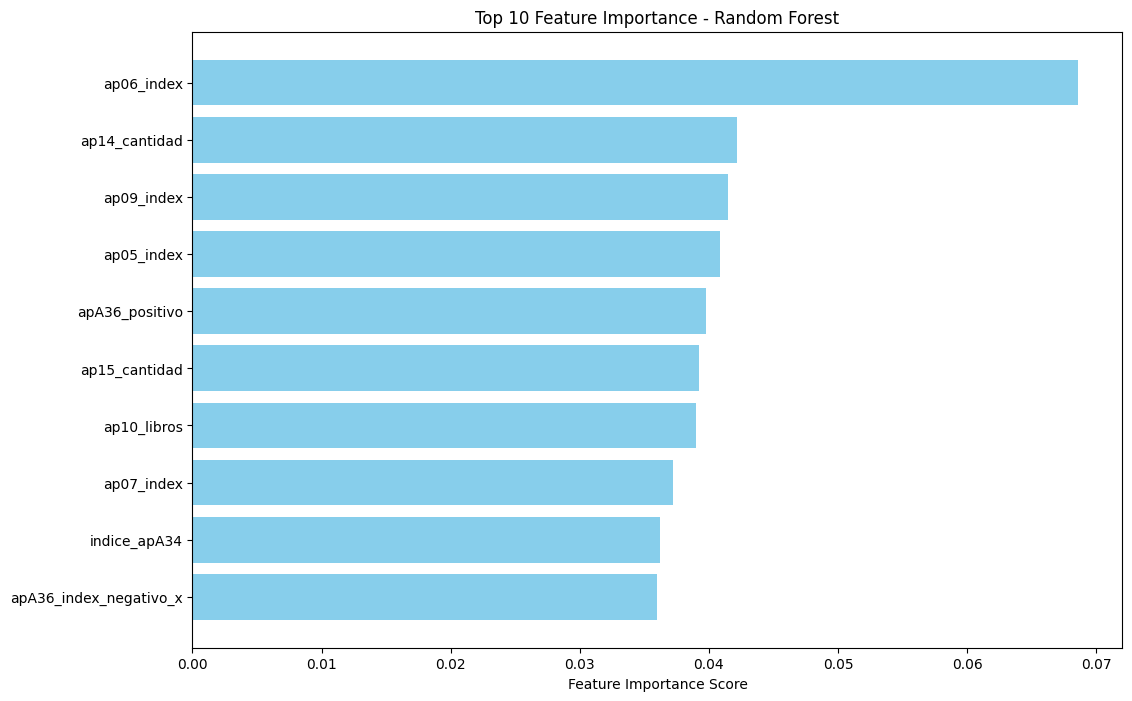


--- Random Forest Model Score on Test Set ---

              precision    recall  f1-score   support

        alto       0.24      0.26      0.25      2245
        bajo       0.63      0.54      0.58      8101
       medio       0.35      0.44      0.39      4342

    accuracy                           0.47     14688
   macro avg       0.41      0.41      0.41     14688
weighted avg       0.49      0.47      0.48     14688



In [59]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# --- ASSUMPTIONS ---
# This code assumes that 'X_train' (scaled features array), 'y_train' (target values),
# and 'X' (the original unscaled DataFrame of features, used for column names)
# have been correctly defined in the preceding cells (e.g., In [52] to In [54]).
# The feature set 'X' already correctly excludes "idalumno" and "ausentismo_cat".
# The original variable "ap23" used to create "ausentismo_cat" is also excluded.
# --------------------

print("--- Starting Random Forest for Feature Importance ---")

# 1. Initialize the Random Forest Classifier
# n_estimators=100 is a good default.
# class_weight='balanced' is used because the target 'ausentismo_cat' is imbalanced.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10, # Limiting depth can help focus on stronger features
    n_jobs=-1     # Use all available cores for faster training
)

# 2. Fit the model to the scaled training data
# This step trains the model and calculates the importance of each feature.
print("Training Random Forest Classifier on scaled data (X_train)...")
rf_model.fit(X_train, y_train)

# 3. Extract and Map Feature Importance
# The feature importances are calculated as a property of the fitted model.
feature_importances = rf_model.feature_importances_

# 4. Create a DataFrame for easy visualization and sorting
importance_df = pd.DataFrame({
    'Feature': X.columns,  # Use column names from the unscaled feature set X
    'Importance': feature_importances
})

# 5. Sort the DataFrame by Importance (descending)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 6. Display the ranked list
print("\n--- Ranked Feature Importance (Top 20) in predicting 'ausentismo_cat' ---\n")
print(importance_df.head(20).to_string(index=False))

# Optional: Visualize the top 10 features
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
top_n = 10
plt.barh(importance_df['Feature'].head(top_n), importance_df['Importance'].head(top_n), color='skyblue')
plt.xlabel('Feature Importance Score')
plt.title(f'Top {top_n} Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

print("\n--- Random Forest Model Score on Test Set ---\n")
# Although the primary goal is importance, let's check the score for context
# NOTE: This step assumes 'X_test' and 'y_test' are also defined.
try:
    from sklearn.metrics import classification_report
    y_pred = rf_model.predict(X_test)
    print(classification_report(y_test, y_pred))
except NameError:
    print("Warning: X_test or y_test not found. Cannot print classification report.")

--- KNN Classification using Top 20 Features ---
Subconjunto de datos creado con 20 variables.
X_train (Top 20) shape: (34270, 20)

Training KNN model on Top 20 features...

--- Evaluation Metrics (KNN - Top 20 Features) ---

Classification Report:
              precision    recall  f1-score   support

        alto       0.52      0.03      0.06      2245
        bajo       0.56      0.88      0.69      8101
       medio       0.33      0.14      0.20      4342

    accuracy                           0.53     14688
   macro avg       0.47      0.35      0.31     14688
weighted avg       0.49      0.53      0.45     14688



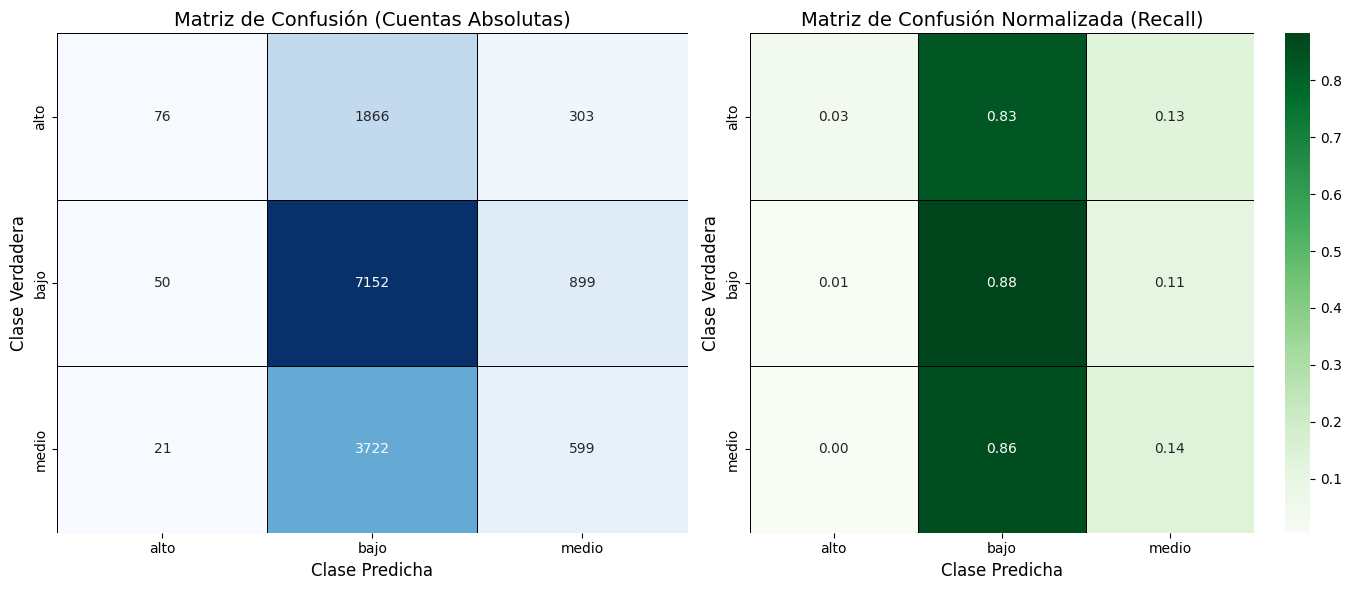

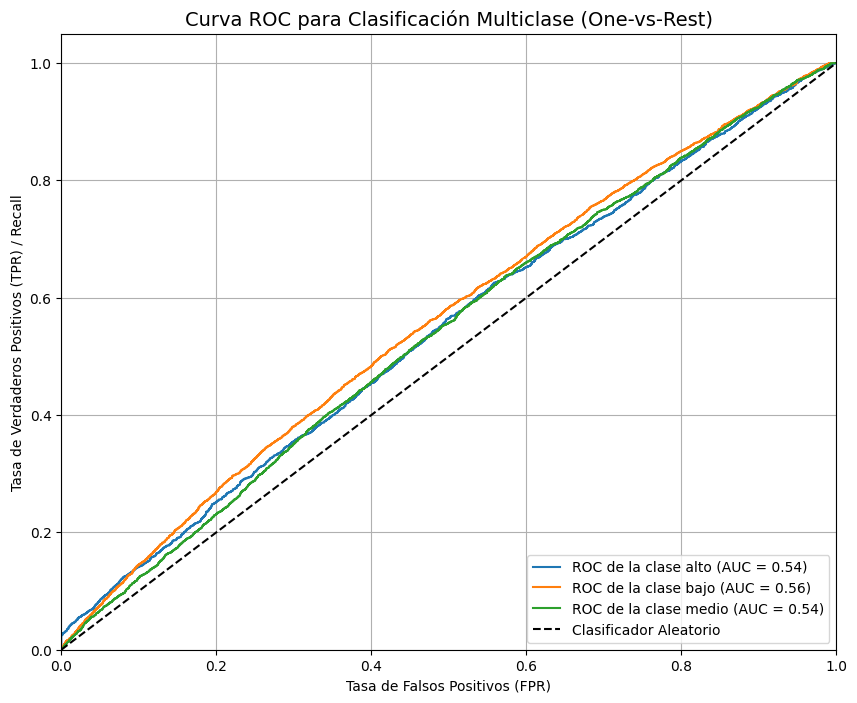

In [61]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # Agregadas para ROC
from sklearn.preprocessing import StandardScaler, LabelBinarizer # Agregado LabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --- ASUNCIONES DE DATOS PREVIOS ---
# Este código asume que el DataFrame de características sin escalar 'X'
# y la serie objetivo 'y' (ausentismo_cat) están disponibles y reflejan
# la eliminación de las columnas 'ap24*' realizada en el paso anterior.
# También asume que X_train, X_test, y_train, y_test existen.
# Si este archivo se ejecuta en un entorno nuevo, se deben ejecutar
# los pasos de preprocesamiento, escalado y split del archivo anterior primero.
# ------------------------------------

print("--- KNN Classification using Top 20 Features ---")

# 1. Definir las 20 variables más importantes (obtenidas del Random Forest)
top_20_features = [
    'ap06_index', 'ap14_cantidad', 'ap09_index', 'ap05_index', 'apA36_positivo',
    'ap15_cantidad', 'ap10_libros', 'ap07_index', 'indice_apA34', 'apA36_index_negativo_x',
    'Nivel_Ed_Padre', 'Nivel_Ed_Madre', 'ldesemp', 'apA36_index_negativo_y', 'mdesemp',
    'ap26', 'ap13_si_no', 'ambito_urbano', 'indice_discriminacion', 'ap01_edad_index'
]

# Función para graficar la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Genera y muestra una matriz de confusión visualmente completa."""
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    
    # Normalizar la matriz para ver proporciones por fila (Recall)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)

    plt.figure(figsize=(14, 6))

    # Gráfico 1: Matriz de confusión con cuentas absolutas
    plt.subplot(1, 2, 1)
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5, linecolor='black')
    plt.title('Matriz de Confusión (Cuentas Absolutas)', fontsize=14)
    plt.ylabel('Clase Verdadera', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)

    # Gráfico 2: Matriz de confusión normalizada (Recall)
    plt.subplot(1, 2, 2)
    sns.heatmap(cm_normalized_df, annot=True, fmt='.2f', cmap='Greens', cbar=True, linewidths=0.5, linecolor='black')
    plt.title('Matriz de Confusión Normalizada (Recall)', fontsize=14)
    plt.ylabel('Clase Verdadera', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)

    plt.tight_layout()
    plt.show()

# Nueva función para graficar la Curva ROC (Multiclase OvR)
def plot_multiclass_roc(y_test, y_score, class_names):
    """Calcula y grafica las curvas ROC para un problema multiclase usando OvR."""
    lb = LabelBinarizer()
    y_test_binarized = lb.fit_transform(y_test)
    
    # Asegurar que el orden de las clases sea consistente
    if len(class_names) != y_test_binarized.shape[1]:
         # Reajustar class_names si LabelBinarizer cambia el orden o las detecta diferente
         class_names = [c for c in lb.classes_]

    n_classes = len(class_names)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 8))
    
    # Calcular ROC y AUC para cada clase (One-vs-Rest)
    for i in range(n_classes):
        # roc_curve necesita las probabilidades de la clase i
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        plt.plot(fpr[i], tpr[i], label=f'ROC de la clase {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio') # Línea de referencia
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
    plt.title('Curva ROC para Clasificación Multiclase (One-vs-Rest)', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


try:
    # 2. Obtener los índices de las columnas del Top 20 dentro del DataFrame X
    feature_indices = [X.columns.get_loc(col) for col in top_20_features]
    
    # 3. Subconjunto de los datos de entrenamiento y prueba
    X_train_top20 = X_train[:, feature_indices]
    X_test_top20 = X_test[:, feature_indices]
    
    print(f"Subconjunto de datos creado con {len(top_20_features)} variables.")
    print(f"X_train (Top 20) shape: {X_train_top20.shape}")

    # 4. Inicializar y entrenar el modelo K-Nearest Neighbors
    knn_model = KNeighborsClassifier(
        n_neighbors=29, 
        weights='distance', 
        n_jobs=-1
    )
    
    print("\nTraining KNN model on Top 20 features...")
    knn_model.fit(X_train_top20, y_train)

    # 5. Realizar predicciones y evaluar el modelo
    y_pred_knn = knn_model.predict(X_test_top20)
    
    # *** NUEVO: Calcular las probabilidades de predicción para la Curva ROC ***
    y_score_knn = knn_model.predict_proba(X_test_top20)

    # Obtener los nombres de las clases en orden
    class_names = np.unique(y_test)

    print("\n--- Evaluation Metrics (KNN - Top 20 Features) ---\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred_knn))

    # 6. Generar la matriz de confusión en un gráfico completo
    plot_confusion_matrix(y_test, y_pred_knn, class_names=class_names)
    
    # 7. Generar la Curva ROC Multiclase
    plot_multiclass_roc(y_test, y_score_knn, class_names=class_names)


except NameError:
    print("\n--- ERROR ---")
    print("Las variables X, X_train, X_test, y_train, o y_test no están definidas.")
    print("Asegúrate de ejecutar primero el código de preprocesamiento y división de datos.")
except KeyError as e:
    print("\n--- ERROR ---")
    print(f"Una de las columnas del top 20 no se encontró en el DataFrame X: {e}")
    print("Verifica que las variables se nombraron correctamente en la lista 'top_20_features'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")